In [1]:
import sys, os
# ensure parent directory is on the path so `src` package can be imported
sys.path.insert(0, os.path.abspath('../..'))

In [2]:
# configura per importare da src
import sys
sys.path.append('./src')

## Box creation

### Calculate progression implications (una tantum first time)

In [3]:
import pandas as pd
df_train = pd.read_csv('../../OAI_Dataset/df_train.csv')

In [ ]:
df_train.head()

In [4]:
df_train['timepoint'].unique()

array([ 0,  6,  8, 10])

In [5]:
len(df_train)

9817

In [14]:
# 1. Definiamo le colonne della sclerosi
sclerosis_cols = ['xrscfm', 'xrsctm', 'xrscfl', 'xrsctl']

# 2. Filtriamo le visite successive al baseline (tutto ciò che NON è '00')
df_followup = df_train[df_train['timepoint'] != 0]

# 3. Contiamo i valori NON nulli (notna)
valid_values_count = df_followup[sclerosis_cols].notna().sum()

print(f"Totale radiografie di follow-up: {len(df_followup)}\n")
print("Numero di annotazioni valide (non-NaN) per la sclerosi nei follow-up:")
print(valid_values_count)

Totale radiografie di follow-up: 8117

Numero di annotazioni valide (non-NaN) per la sclerosi nei follow-up:
xrscfm    99
xrsctm    99
xrscfl    99
xrsctl    99
dtype: int64


In [17]:
from src.utils.dataset import VISUAL_CONCEPTS
# Mostra quante annotazioni valide ci sono per ogni timepoint
storico_annotazioni = df_train.groupby('timepoint')[VISUAL_CONCEPTS].count()

print("Conteggio annotazioni valide per ogni timepoint:")
print(storico_annotazioni)

Conteggio annotazioni valide per ogni timepoint:
           xrosfm  xrscfm  xrjsm  xrostm  xrsctm  xrosfl  xrscfl  xrjsl  \
timepoint                                                                 
0             890     526   1700     890     526     890     526   1700   
6             178      99    404     178      99     178      99    404   
8             501       0   3057     501       0     497       0   3057   
10            733       0   4655     730       0     724       0   4654   

           xrostl  xrsctl  
timepoint                  
0             890     526  
6             178      99  
8             500       0  
10            730       0  


In [16]:
from src.utils.box import calculate_longitudinal_transitions
from src.utils.dataset import VISUAL_CONCEPTS

thresholds = [1.0, 2.0, 3.0]
NO_SCLEROSIS_VISUAL_CONCEPTS = [
    'xrosfm', # Osteofiti (Femore Mediale)
    'xrjsm',  # Restringimento Spazio Articolare (Mediale)
    'xrostm', # Osteofiti (Tibia Mediale)
    'xrosfl', # Osteofiti (Femore Laterale)
    'xrjsl',  # Restringimento Spazio Articolare (Laterale)
    'xrostl', # Osteofiti (Tibia Laterale)
]
concept_implications_ts_df = calculate_longitudinal_transitions(df_train, NO_SCLEROSIS_VISUAL_CONCEPTS, thresholds=thresholds)

In [17]:
import torch
# 1. Conversione da DataFrame a Tensore PyTorch
# ATTENZIONE: Pandas usa di default float64, ma la tua ResNet-18 e i Box Embeddings 
# lavoreranno in float32. Forzare il dtype previene fastidiosi errori di mismatch durante il forward pass.
concept_implications_ts = torch.tensor(concept_implications_ts_df.values, dtype=torch.float32)

# 2. Spostamento sul device di calcolo
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
concept_implications_ts = concept_implications_ts.to(device)

# Verifica rapida
print(f"Shape del tensore: {concept_implications_ts.shape}")  # Es: torch.Size([40, 40])
print(f"Tipo di dato: {concept_implications_ts.dtype}")       # torch.float32
print(f"Device: {concept_implications_ts.device}")    

Shape del tensore: torch.Size([18, 18])
Tipo di dato: torch.float32
Device: cpu


In [18]:
# Salva il tensore in un file .pt
torch.save(concept_implications_ts, 'oai_empirical_progression.pt')
print("Matrice delle probabilità salvata con successo.")

Matrice delle probabilità salvata con successo.


### Load Ground Truth

In [3]:
from src.utils.dataset import VISUAL_CONCEPTS, TIMEPOINT_MAP, BASE_COLS_TO_KEEP, TARGET_COL
# Carica il tensore direttamente nel device desiderato
import torch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
concept_causal_progression = torch.load('../../OAI_Dataset/oai_empirical_progression.pt', map_location=device)

In [5]:
# Dal tuo file di configurazione
CLASSES_PER_COLUMN = {
    'xrosfm': 4, 
    'xrjsm': 4, 
    'xrostm': 4,  
    'xrosfl': 4,  
    'xrjsl': 4,
    'xrostl': 4, 
}

NO_SCLEROSIS_VISUAL_CONCEPTS = [
    'xrosfm', # Osteofiti (Femore Mediale)
    'xrjsm',  # Restringimento Spazio Articolare (Mediale)
    'xrostm', # Osteofiti (Tibia Mediale)
    'xrosfl', # Osteofiti (Femore Laterale)
    'xrjsl',  # Restringimento Spazio Articolare (Laterale)
    'xrostl', # Osteofiti (Tibia Laterale)
]

# 1. Generiamo la lista espansa VISUAL_CONCEPTS
NO_SCLEROSIS_VISUAL_CONCEPTS_EXTENDED = []
for concept in NO_SCLEROSIS_VISUAL_CONCEPTS:
    # Se le classi sono 4 (0, 1, 2, 3), le soglie saranno 1.0, 2.0, 3.0
    # Escludiamo lo 0 perché rappresenta l'assenza del sintomo (nessun box)
    max_classes = CLASSES_PER_COLUMN[concept]
    
    for threshold in range(1, max_classes):
        # Aggiungiamo la stringa formattata esattamente come nella matrice Pandas
        NO_SCLEROSIS_VISUAL_CONCEPTS_EXTENDED.append(f"{concept}_>={float(threshold)}")

# 2. Creazione dei dizionari di mappatura
id2concept = {i: concept for i, concept in enumerate(NO_SCLEROSIS_VISUAL_CONCEPTS_EXTENDED)}
concept2id = {concept: i for i, concept in enumerate(NO_SCLEROSIS_VISUAL_CONCEPTS_EXTENDED)}

AllenNLP not available. Registrable won't work.


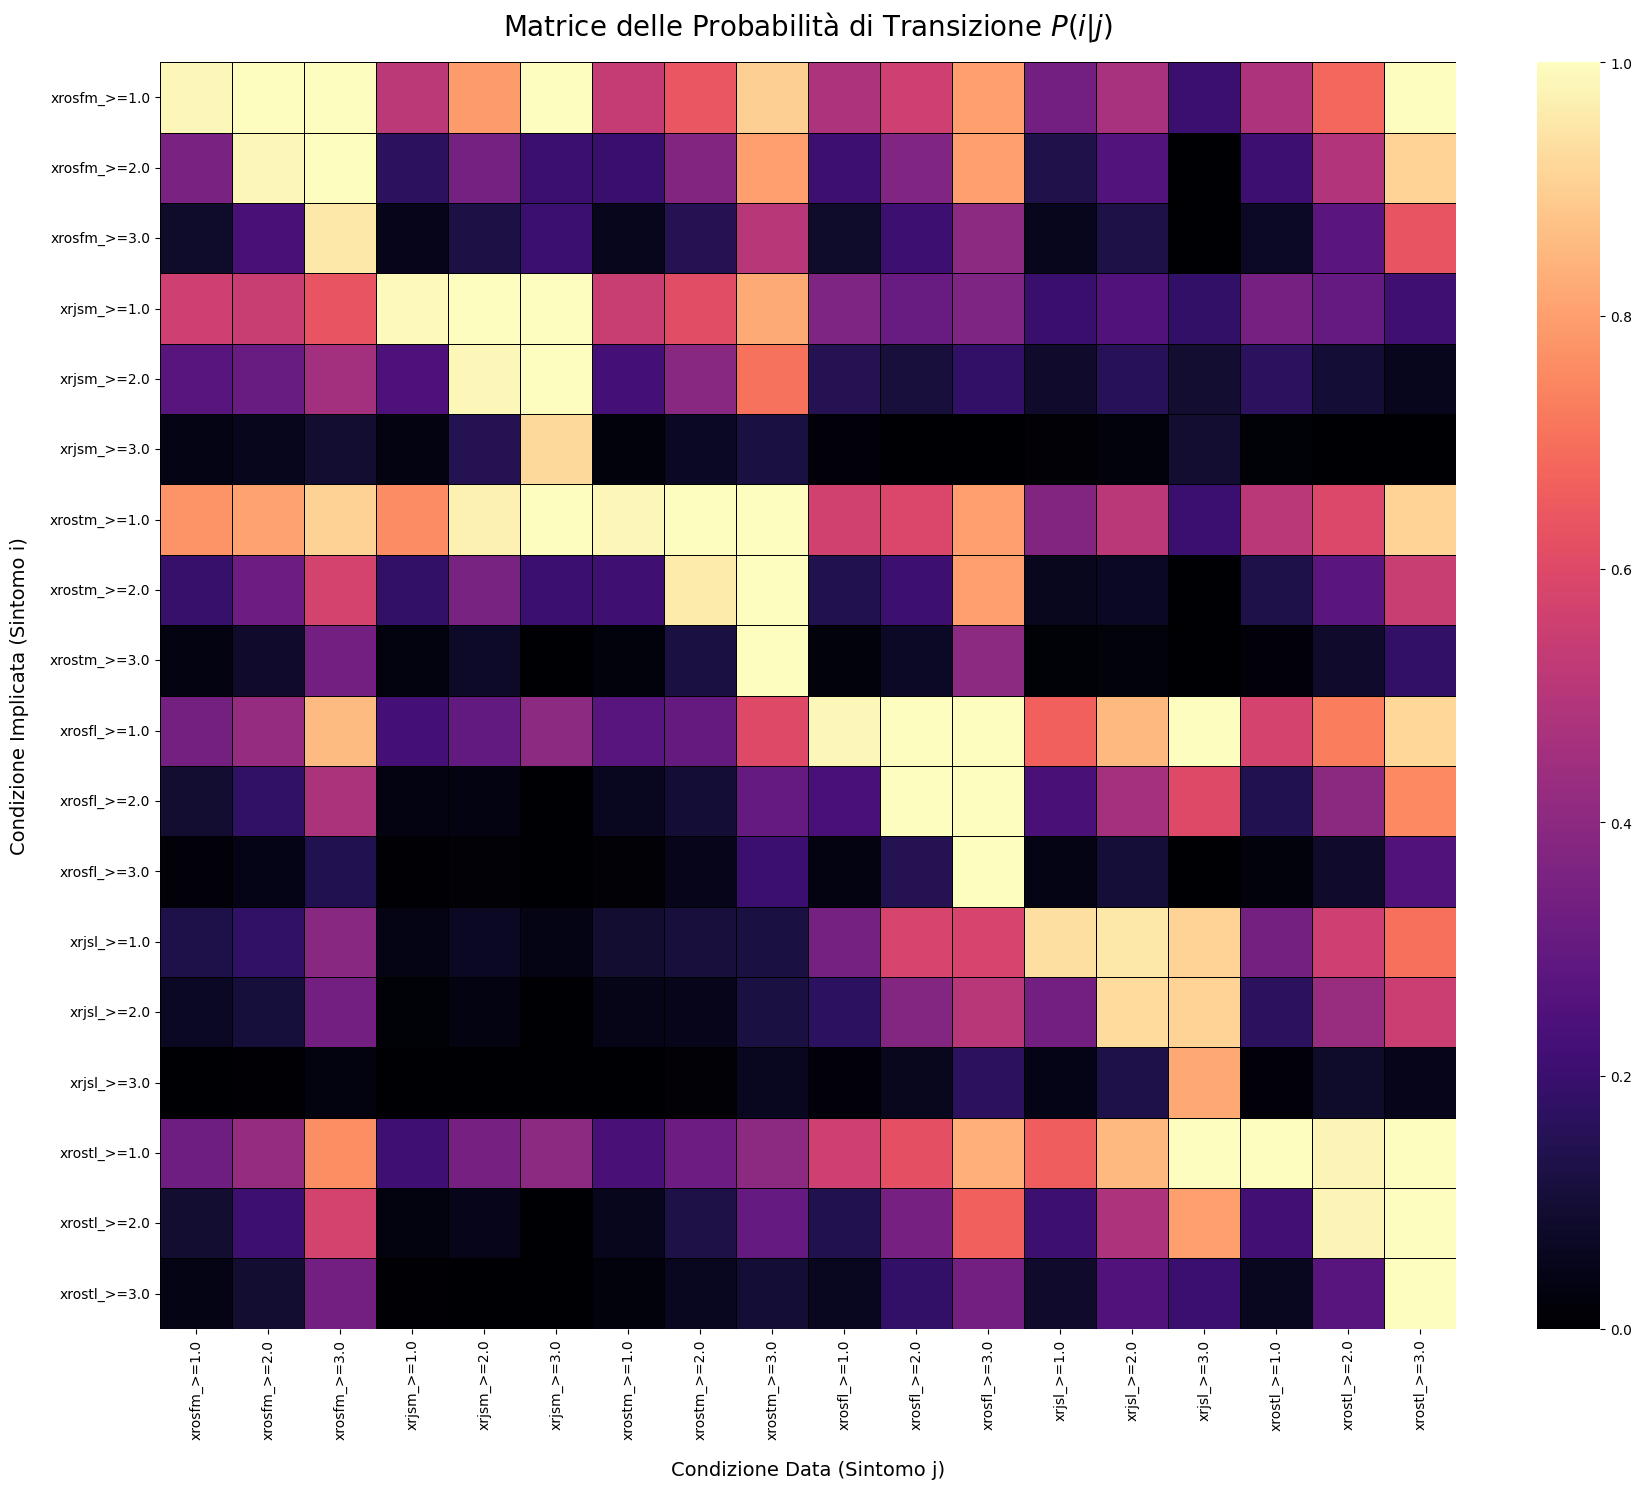

In [6]:
from src.utils.plot import plot_clinical_heatmap
labels = list(NO_SCLEROSIS_VISUAL_CONCEPTS_EXTENDED)
plot_clinical_heatmap(concept_causal_progression, concept_labels=labels)

### Train

In [7]:
from src.CHM.model import BoxHierarchyModel
from src.CHM.train import train_box_empirical
import torch.nn as nn
from torch.optim import Adam

LR = 0.005

box_model = BoxHierarchyModel(num_concepts=concept_causal_progression.shape[0], dim=8, soft_intersection=True)
optimizer = Adam(box_model.parameters(), lr=LR)
criterion = nn.BCELoss()

In [8]:
box_model = train_box_empirical(
    box_model, 
    concept_causal_progression, 
    optimizer, 
    criterion,
    epochs=100,
)

Epoch 1/100 | Tot: 2.2722 | Fit: 2.2722 | Vol: 0.0000
Epoch 10/100 | Tot: 0.8634 | Fit: 0.8634 | Vol: 0.0000
Epoch 20/100 | Tot: 0.6896 | Fit: 0.6896 | Vol: 0.0000
Epoch 30/100 | Tot: 0.6202 | Fit: 0.6202 | Vol: 0.0000
Epoch 40/100 | Tot: 0.5807 | Fit: 0.5807 | Vol: 0.0000
Epoch 50/100 | Tot: 0.5543 | Fit: 0.5543 | Vol: 0.0000
Epoch 60/100 | Tot: 0.5349 | Fit: 0.5349 | Vol: 0.0000
Epoch 70/100 | Tot: 0.5195 | Fit: 0.5195 | Vol: 0.0000
Epoch 80/100 | Tot: 0.5070 | Fit: 0.5070 | Vol: 0.0000
Epoch 90/100 | Tot: 0.4967 | Fit: 0.4967 | Vol: 0.0000
Epoch 100/100 | Tot: 0.4877 | Fit: 0.4877 | Vol: 0.0000
Addestramento completato!


### Visualization

In [9]:
from src.CHM.visualization import visualize_concept_hierarchy, visualize_heatmap_compare, visualize_all_boxes_2d

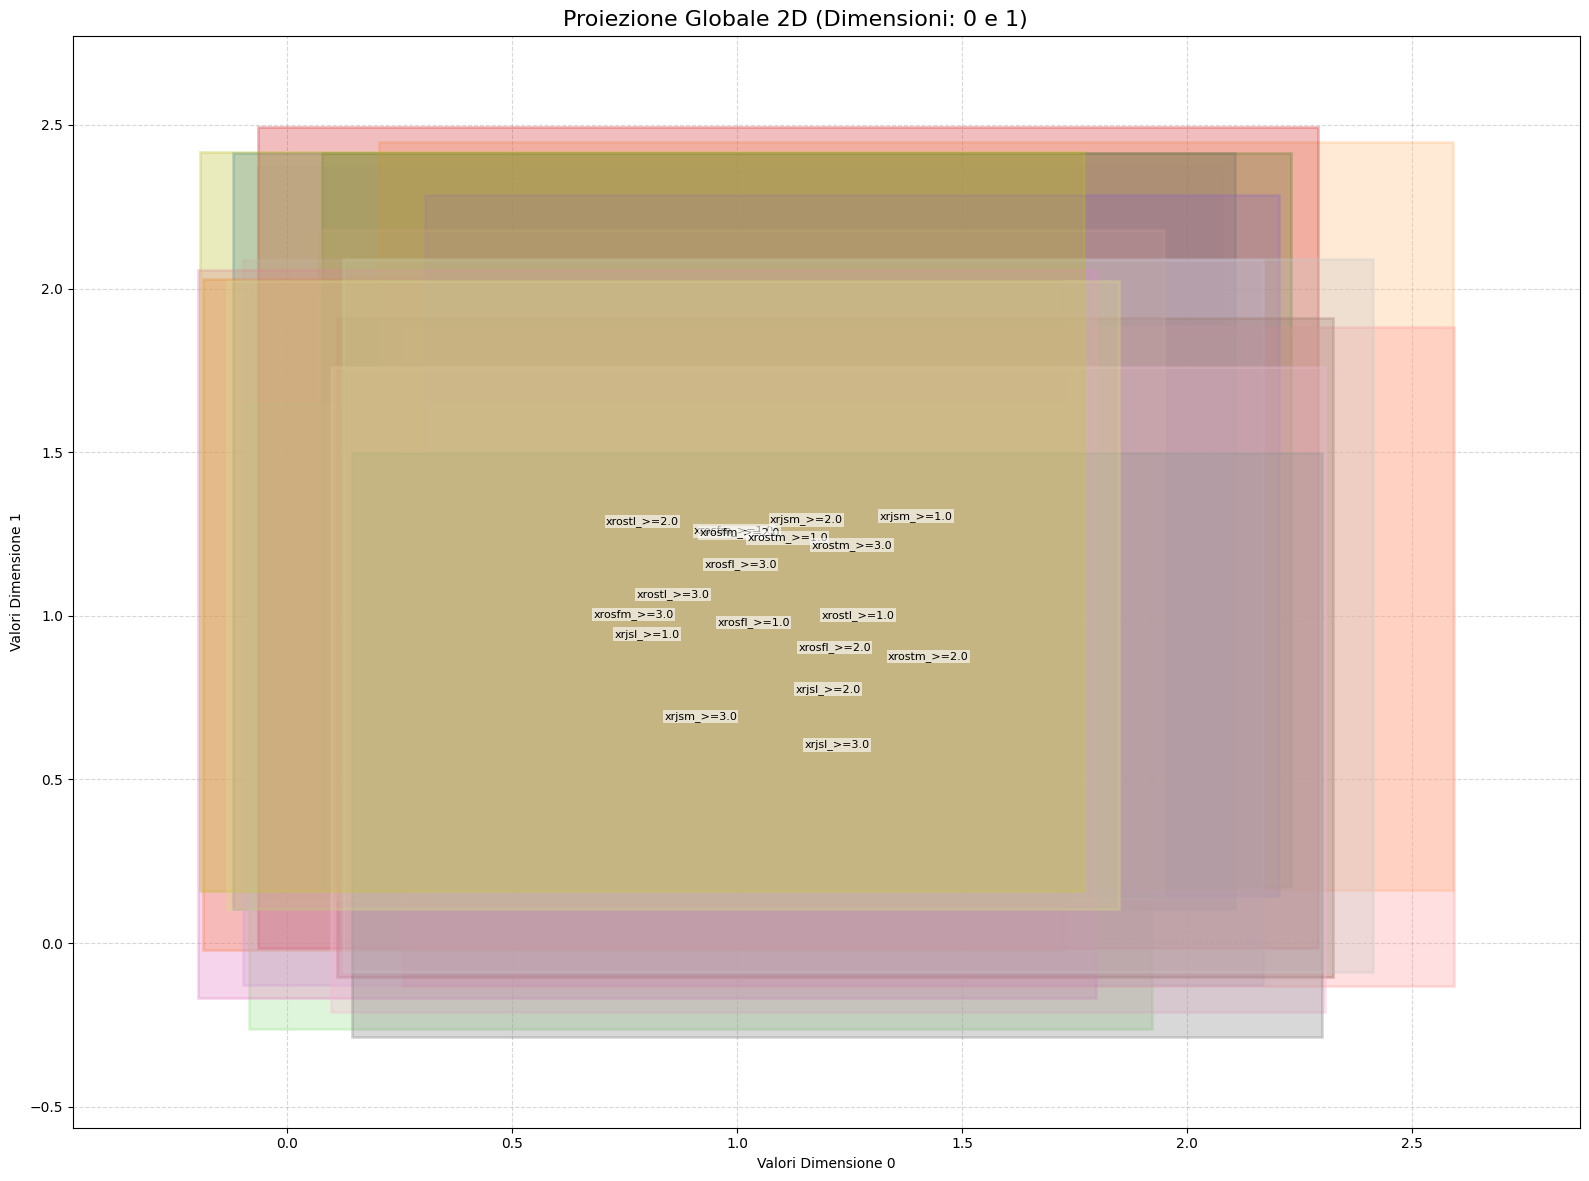

In [10]:
# cambiare dim_x e dim_y (da 0 a 31) per esplorare la "forma" da diverse angolazioni
visualize_all_boxes_2d(box_model, id2concept, dim_x=0, dim_y=1)

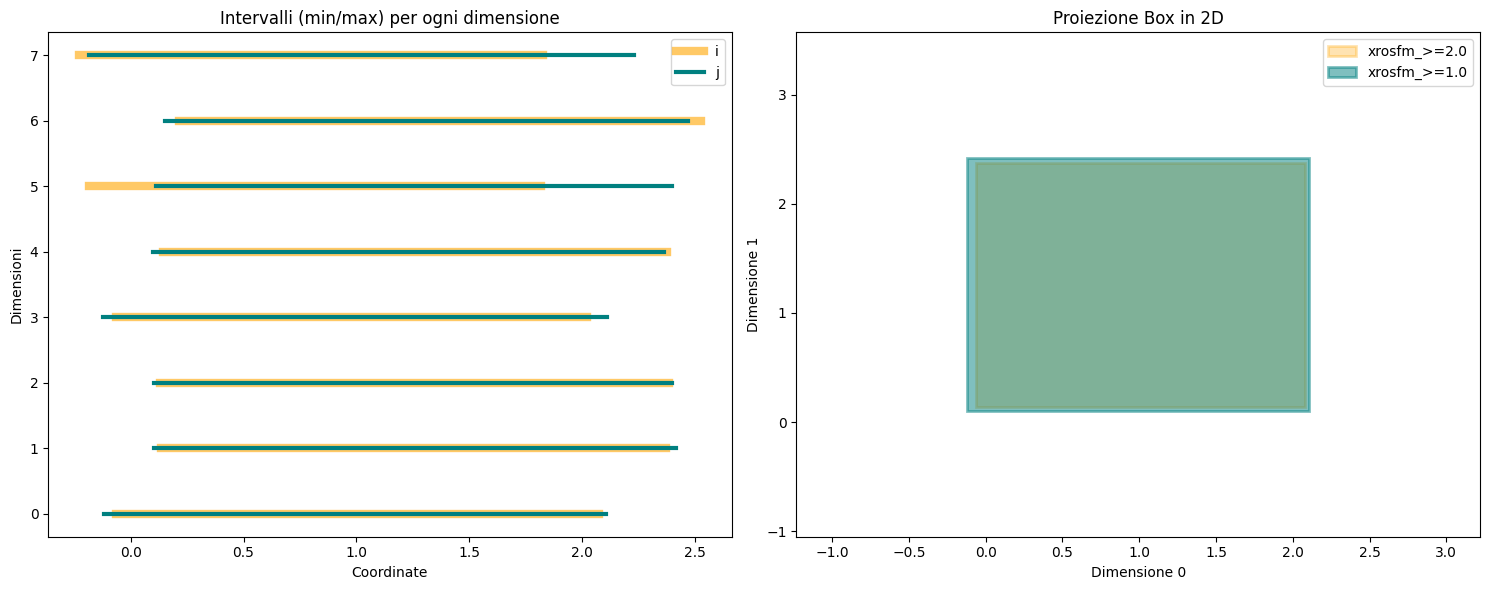

In [11]:
visualize_concept_hierarchy(box_model, id2concept, concept2id, "xrosfm_>=2.0", "xrosfm_>=1.0")

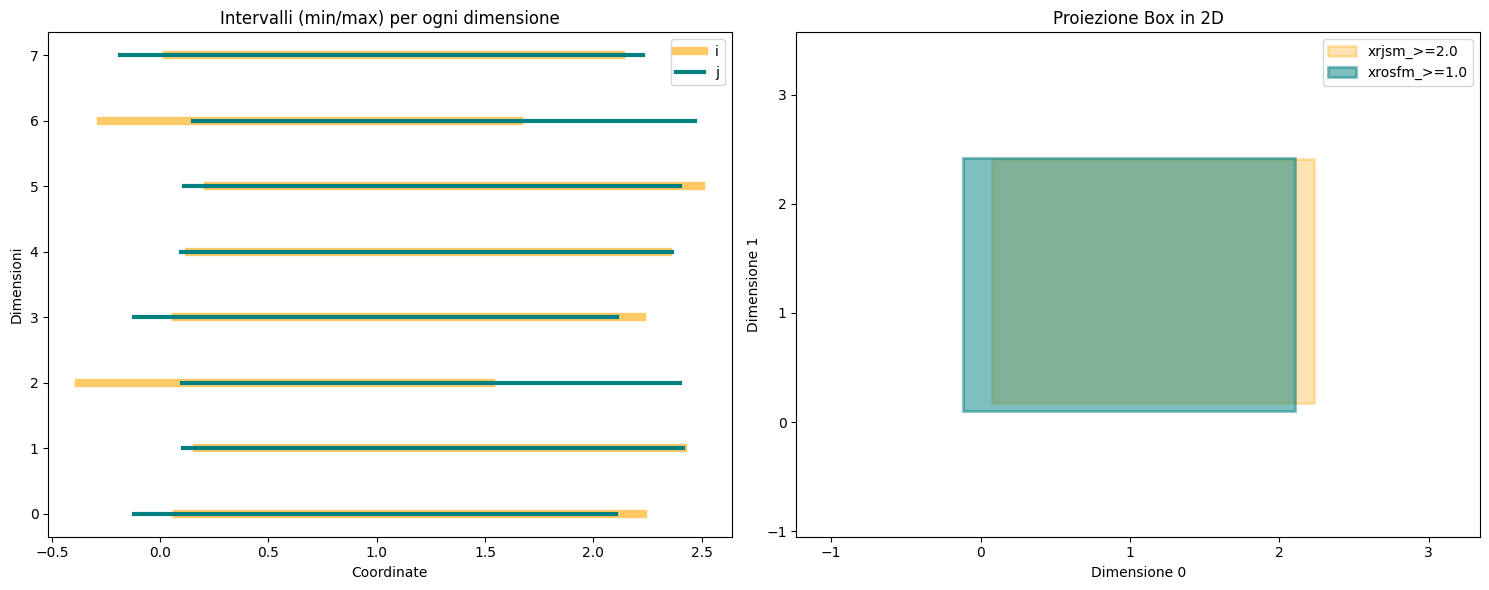

In [12]:
visualize_concept_hierarchy(box_model, id2concept, concept2id, "xrjsm_>=2.0", "xrosfm_>=1.0")

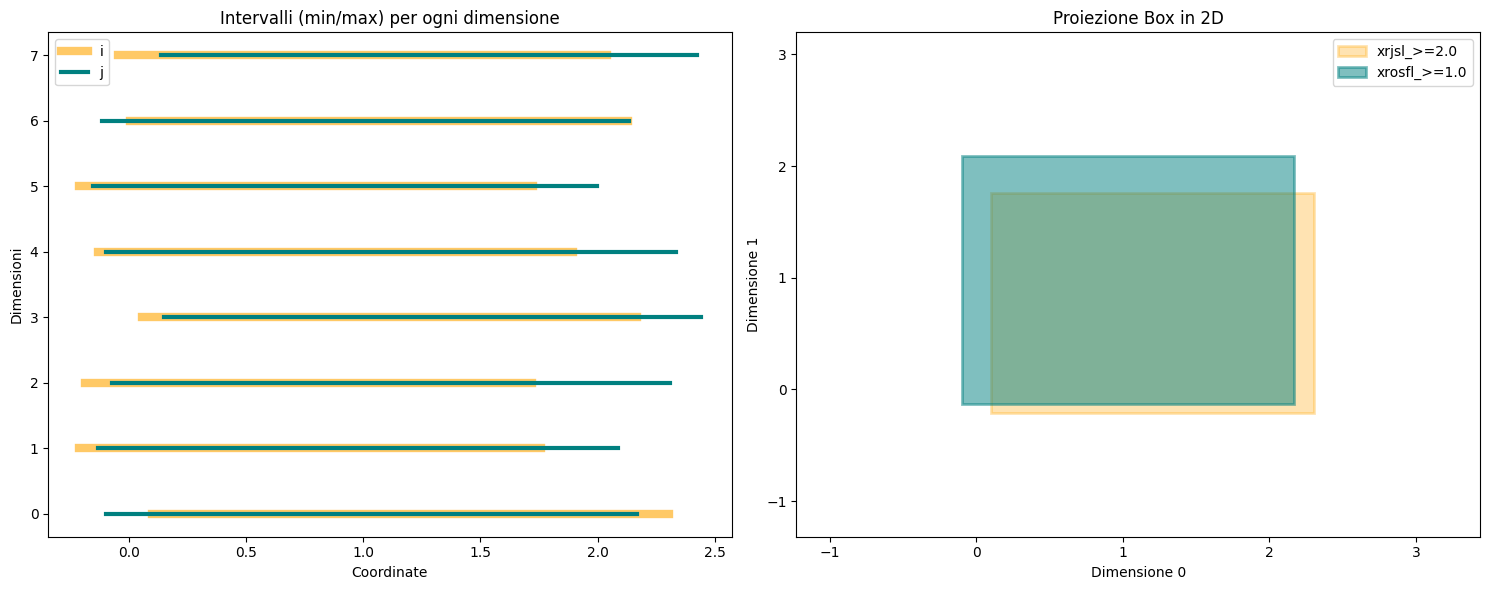

In [13]:
visualize_concept_hierarchy(box_model, id2concept, concept2id, "xrjsl_>=2.0", "xrosfl_>=1.0")

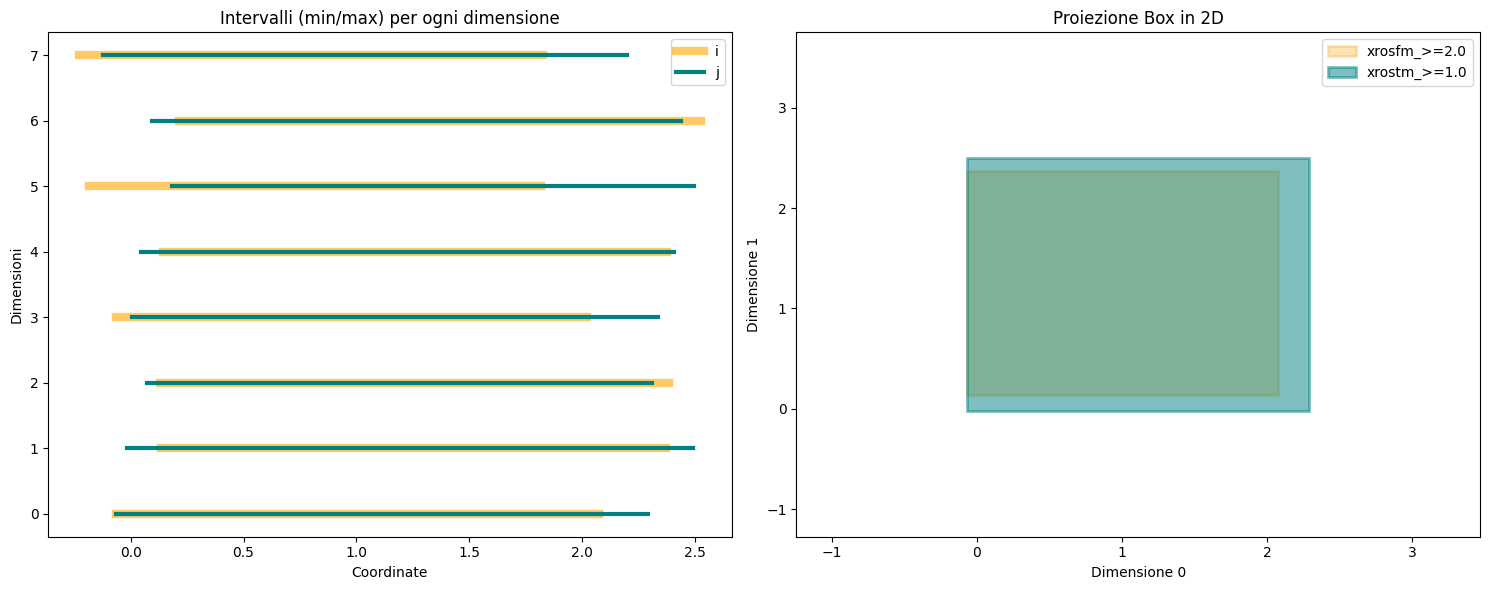

In [14]:
visualize_concept_hierarchy(box_model, id2concept, concept2id, "xrosfm_>=2.0", "xrostm_>=1.0")

In [ ]:
from src.utils.box import extract_hierarchy
import networkx as nx
import matplotlib.pyplot as plt
from networkx.drawing.nx_pydot import pydot_layout

plt.figure(figsize=(60, 30))


hierarchy_graph = extract_hierarchy(box_model, num_concepts=len(VISUAL_CONCEPTS_EXTENDED), concept_names=VISUAL_CONCEPTS_EXTENDED)
pos = pydot_layout(hierarchy_graph, prog="dot")

nx.draw_networkx(
     hierarchy_graph, 
     labels=nx.get_node_attributes(hierarchy_graph, 'label'),
     node_size=1500, 
     node_color="lightblue", 
     font_size=8,
     pos=pos,
     font_weight="bold",
     edge_color="gray",
     arrows=True,
     arrowsize=15,       # Frecce ben visibili per indicare la direzione
     arrowstyle="-|>"
)
plt.title("Gerarchia dei Concetti AWA2 estratta dai Box Embeddings", fontsize=16)
plt.axis("off") # Rimuove il bordo e le coordinate dal grafico
plt.tight_layout()
plt.show()

### Save boxes

In [ ]:
from src.utils.box import get_box_dict

box_dict = get_box_dict(box_model, id2concept)

## CBM

### Load dataset

In [ ]:
import torch
torch.save(box_model.state_dict(), "modello_gerarchia.pth")

In [ ]:
box_model.load_state_dict(torch.load("modello_gerarchia.pth"))

In [ ]:
from src.utils.box import get_box_dict
box_dict = get_box_dict(box_model, id2concept)

In [ ]:
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
from src.utils.box import prepara_tensore_box

box_tensors = prepara_tensore_box(box_dict, concept2id)

BOX_DIM = 32
BATCH_SIZE = 32
EPOCHS = 5
NUM_CLASSES = len(set(y_train))
NUM_CONCEPTS = len(concept2id)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

train_dataset = TensorDataset(torch.tensor(X_train).float(), torch.tensor(y_train).long())
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, pin_memory=True)
val_dataset = TensorDataset(torch.tensor(X_val).float(), torch.tensor(y_val).long())
val_dataloader = DataLoader(val_dataset, batch_size=BATCH_SIZE, pin_memory=True)
test_dataset = TensorDataset(torch.tensor(X_test).float(), torch.tensor(y_test).long())
test_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE, pin_memory=True)

In [ ]:
from src.CHM.model import ConceptBottleneckClassifier
from src.CHM.train import train_cbm_classifier
import matplotlib.pyplot as plt
from src.CHM.test import test_cbm_classifier
from src.utils.plot import plot_test_results, plot_concept_error_heatmap, analyze_misclassifications_concepts, plot_concept_uncertainty_heatmap

### CBM with boxes

#### Train

In [ ]:
b_model = ConceptBottleneckClassifier(box_dim=box_tensors.size(-1), num_classes=NUM_CLASSES, num_concepts=NUM_CONCEPTS)
optimizer = torch.optim.Adam(b_model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

info = "boxes"

b_history = train_cbm_classifier(
    b_model, 
    train_dataloader, 
    val_dataloader, 
    optimizer, 
    criterion, 
    class_concept_matrix, 
    box_tensors, 
    EPOCHS, 
    device
)

In [ ]:
from src.utils.plot import plot_history
plot_history(b_history)

#### Test

In [ ]:
accuracy, preds, labels, _, _, _ = test_cbm_classifier(
     model=b_model,
     test_dataloader=test_dataloader,
     class_concept_matrix=class_concept_matrix,
     boxes_tensor=box_tensors,
     oracle=True,
     device="cuda" if torch.cuda.is_available() else "cpu"
)

In [ ]:
plot_test_results(accuracy, preds, labels, class_names=classes)

In [ ]:
from src.CHM.interpretation import explain_prediction

explain_prediction(b_model, test_dataloader, concepts, classes, class_concept_matrix, box_tensors, target_class="chihuahua")

### CBM with cond prob distrib

#### Train

In [ ]:
info = "rel_matrix"
bipolar = True
cp_model = ConceptBottleneckClassifier(box_dim=box_tensors.size(-1), num_classes=NUM_CLASSES, num_concepts=NUM_CONCEPTS, info=info)
optimizer = torch.optim.Adam(cp_model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()
cp_history = train_cbm_classifier(
    cp_model, 
    train_dataloader, 
    val_dataloader, 
    optimizer, 
    criterion, 
    class_concept_matrix, 
    box_tensors, 
    EPOCHS, 
    device,
    info=info,
    bipolar=bipolar
)

In [ ]:
from src.utils.plot import plot_history
plot_history(cp_history)

#### Test

In [ ]:
cp_accuracy, cp_preds, cp_labels, _, _, _ = test_cbm_classifier(
     model=cp_model,
     test_dataloader=test_dataloader,
     class_concept_matrix=class_concept_matrix,
     boxes_tensor=box_tensors,
     device="cuda" if torch.cuda.is_available() else "cpu",
     info=info,
     bipolar=bipolar,
     oracle=True,
)

In [ ]:
plot_test_results(accuracy, preds, labels, class_names=classes)

In [ ]:
from src.CHM.interpretation import explain_prediction

explain_prediction(
    cp_model, 
    test_dataloader, 
    concepts, 
    classes, 
    class_concept_matrix, 
    box_tensors, 
    info_type=info, 
    target_class="chihuahua", 
    bipolar=bipolar
)

### CBM standard

In [ ]:
info = "concepts"
c_model = ConceptBottleneckClassifier(box_dim=box_tensors.size(-1), num_classes=NUM_CLASSES, num_concepts=NUM_CONCEPTS, info=info)
optimizer = torch.optim.Adam(c_model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()
c_history = train_cbm_classifier(
    c_model, 
    train_dataloader, 
    val_dataloader, 
    optimizer, 
    criterion, 
    class_concept_matrix, 
    box_tensors, 
    EPOCHS, 
    device,
    info=info
)

In [ ]:
from src.utils.plot import plot_history
plot_history(c_history)

In [ ]:
c_accuracy, c_preds, c_labels, _, _, _ = test_cbm_classifier(
     model=c_model,
     test_dataloader=test_dataloader,
     class_concept_matrix=class_concept_matrix,
     boxes_tensor=box_tensors,
     device="cuda" if torch.cuda.is_available() else "cpu",
     info=info,
     oracle=True,
)

In [ ]:
plot_test_results(c_accuracy, c_preds, c_labels, class_names=classes)

In [ ]:
from src.CHM.interpretation import explain_prediction

explain_prediction(c_model, test_dataloader, concepts, classes, class_concept_matrix, box_tensors, info_type=info)

## Independent

### CONCEPT PREDICTOR

In [ ]:
from src.CP.model import ConceptPredictor

concept_predictor = ConceptPredictor(X_train.shape[1], num_concepts=NUM_CONCEPTS)
optimizer = torch.optim.Adam(concept_predictor.parameters(), lr=0.001)
criterion = nn.BCEWithLogitsLoss()

In [ ]:
from src.CHM.train import train_concept_predictor

history = train_concept_predictor(
    concept_predictor, 
    train_dataloader, 
    val_dataloader, 
    class_concept_matrix, 
    optimizer, 
    criterion, 
    EPOCHS, 
    device
)

### BOXES

In [ ]:
info = "boxes"
b_accuracy, b_preds, b_labels, b_concepts_preds, b_concepts_truth, b_concepts_probs = test_cbm_classifier(
     model=b_model,
     test_dataloader=test_dataloader,
     class_concept_matrix=class_concept_matrix,
     boxes_tensor=box_tensors,
     device="cuda" if torch.cuda.is_available() else "cpu",
     info=info,
     bipolar=False,
     oracle=False,
     concept_predictor=concept_predictor
)

In [ ]:
info = "boxes"
b_accuracy, b_preds, b_labels, b_concepts_preds, b_concepts_truth, b_concepts_probs = test_cbm_classifier(
     model=b_model,
     test_dataloader=test_dataloader,
     class_concept_matrix=class_concept_matrix,
     boxes_tensor=box_tensors,
     device="cuda" if torch.cuda.is_available() else "cpu",
     info=info,
     bipolar=False,
     oracle=False,
     concept_predictor=concept_predictor,
     smoothing_logic=True
)

#### STATS 

In [ ]:
plot_test_results(b_accuracy, b_preds, b_labels, class_names=classes)

In [ ]:
plot_concept_error_heatmap(labels,b_concepts_preds, b_concepts_truth, classes, concepts)

In [ ]:
analyze_misclassifications_concepts(b_preds, b_labels, b_concepts_preds, b_concepts_truth, classes, concepts, num_examples=10)

In [ ]:
plot_concept_uncertainty_heatmap(labels, b_concepts_probs, class_names=classes, concept_names=concepts)

#### TEST TIME INTERVENTION

In [ ]:
from src.utils.plot import plot_intervention_curve
plot_intervention_curve(
    k_values=[0,1,2,3,4,5,10,20,25,30],
    model=b_model,
    test_loader=test_dataloader,
    class_concept_matrix=class_concept_matrix,
    boxes_tensor=box_tensors,
    device=device,
    info=info,
    concept_predictor=concept_predictor
)

### RELATION MATRIX

In [ ]:
info = "rel_matrix"
cp_accuracy, cp_preds, cp_labels, cp_concepts_preds, cp_concepts_truth, cp_concepts_probs = test_cbm_classifier(
     model=cp_model,
     test_dataloader=test_dataloader,
     class_concept_matrix=class_concept_matrix,
     boxes_tensor=box_tensors,
     device="cuda" if torch.cuda.is_available() else "cpu",
     info=info,
     bipolar=False,
     oracle=False,
     concept_predictor=concept_predictor
)

In [ ]:
plot_test_results(cp_accuracy, cp_preds, cp_labels, class_names=classes)

In [ ]:
info = "rel_matrix"
cp_accuracy, cp_preds, cp_labels, cp_concepts_preds, cp_concepts_truth, cp_concepts_probs = test_cbm_classifier(
     model=cp_model,
     test_dataloader=test_dataloader,
     class_concept_matrix=class_concept_matrix,
     boxes_tensor=box_tensors,
     device="cuda" if torch.cuda.is_available() else "cpu",
     info=info,
     bipolar=True,
     oracle=False,
     concept_predictor=concept_predictor,
     smoothing_logic=True,
     alpha=0.95
)

In [ ]:
plot_test_results(cp_accuracy, cp_preds, cp_labels, class_names=classes)

### STANDARD CBM

In [ ]:
info = "concepts"
c_accuracy, c_preds, c_labels, b_concepts_preds, b_concepts_truth, b_concepts_probs = test_cbm_classifier(
     model=c_model,
     test_dataloader=test_dataloader,
     class_concept_matrix=class_concept_matrix,
     boxes_tensor=box_tensors,
     device="cuda" if torch.cuda.is_available() else "cpu",
     info=info,
     bipolar=False,
     oracle=False,
     concept_predictor=concept_predictor
)

In [ ]:
plot_test_results(c_accuracy, c_preds, c_labels, class_names=classes)

In [ ]:
info = "concepts"
c_accuracy, c_preds, c_labels, b_concepts_preds, b_concepts_truth, b_concepts_probs = test_cbm_classifier(
     model=c_model,
     test_dataloader=test_dataloader,
     class_concept_matrix=class_concept_matrix,
     boxes_tensor=box_tensors,
     device="cuda" if torch.cuda.is_available() else "cpu",
     info=info,
     bipolar=False,
     oracle=False,
     concept_predictor=concept_predictor,
     smoothing_logic=True,
     alpha=0.95
)